In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rc('image', cmap='gray')

In [5]:
dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

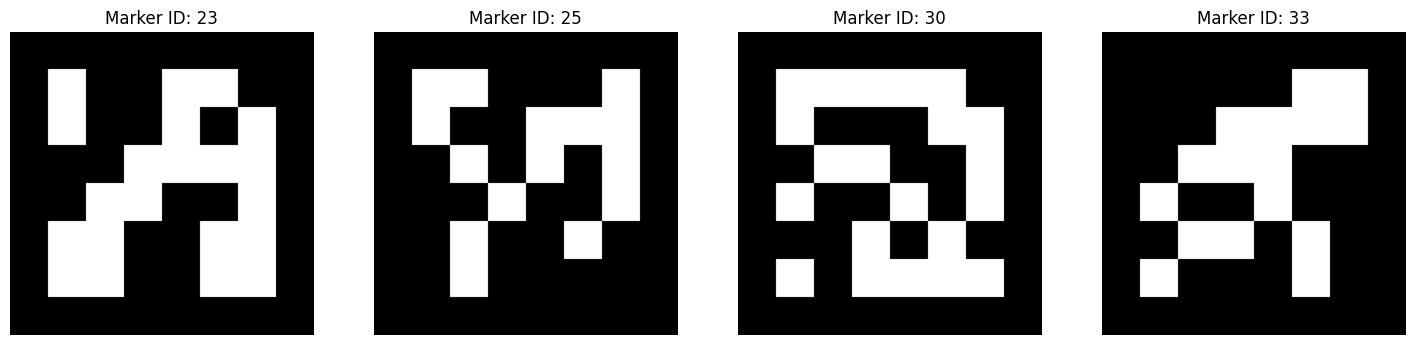

In [6]:
marker_image1 = cv2.aruco.generateImageMarker(dictionary, 23, 200)
marker_image2 = cv2.aruco.generateImageMarker(dictionary, 25, 200)
marker_image3 = cv2.aruco.generateImageMarker(dictionary, 30, 200)
marker_image4 = cv2.aruco.generateImageMarker(dictionary, 33, 200)

plt.figure(figsize=(18, 10))
plt.subplot(141);plt.imshow(marker_image1);plt.title("Marker ID: 23");plt.axis("off")
plt.subplot(142);plt.imshow(marker_image2);plt.title("Marker ID: 25");plt.axis("off")
plt.subplot(143);plt.imshow(marker_image3);plt.title("Marker ID: 30");plt.axis("off")
plt.subplot(144);plt.imshow(marker_image4);plt.title("Marker ID: 33");plt.axis("off")

In [7]:
frame = cv2.imread('data/images/marker_23_printed.png')

corners, ids, rejected = cv2.aruco.ArucoDetector(dictionary).detectMarkers(frame)

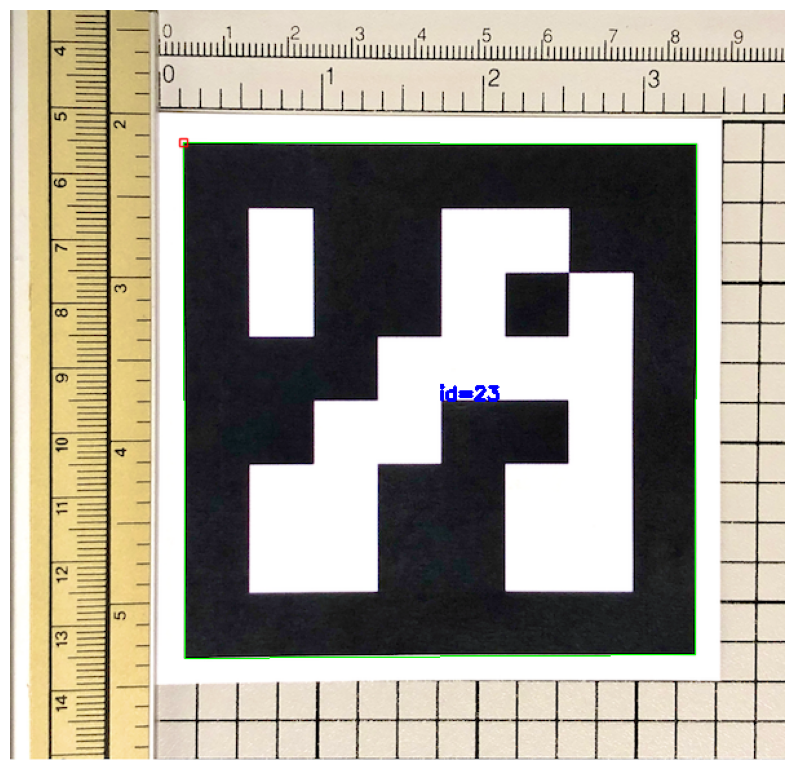

In [12]:
cv2.aruco.drawDetectedMarkers(frame, corners, ids)
plt.figure(figsize=(10, 10))
plt.axis('off')
plt.imshow(frame[...,::-1])

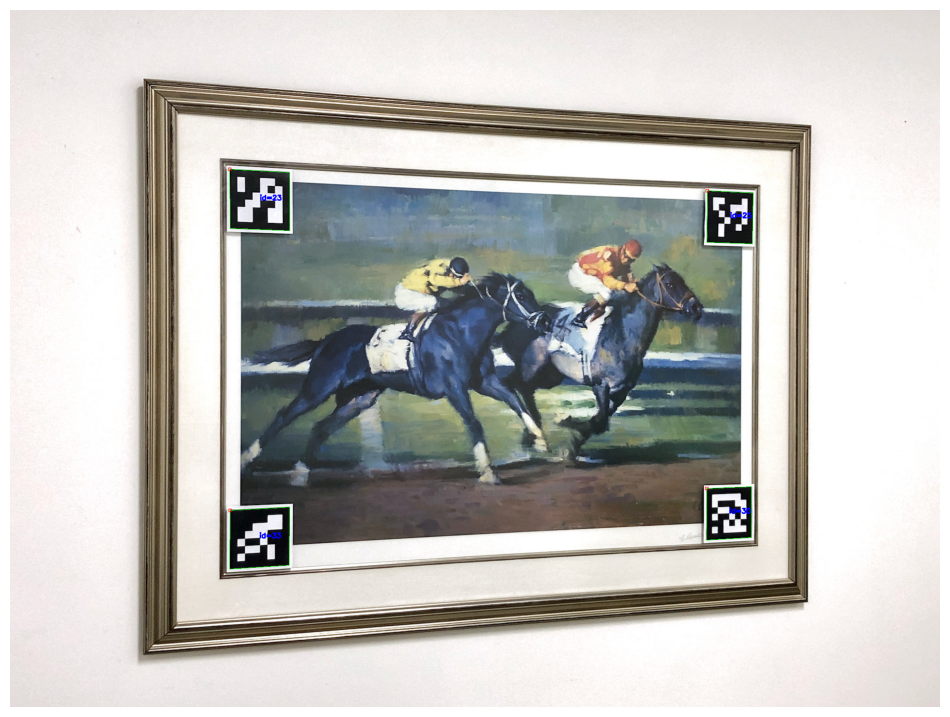

In [13]:
frame_dst = cv2.imread('data/images/office_markers.jpg')

corners, ids, rejected = cv2.aruco.detectMarkers(frame_dst, dictionary)

frame_detected = frame_dst.copy()

cv2.aruco.drawDetectedMarkers(frame_detected, corners, ids)
plt.figure(figsize=[12, 12])
plt.axis('off')
plt.imshow(frame_detected[...,::-1])

In [14]:
index = np.squeeze(np.where(ids==23))
ref_pt1 = np.squeeze(corners[index[0]])[0]

index = np.squeeze(np.where(ids==25))
ref_pt2 = np.squeeze(corners[index[0]])[1]

index = np.squeeze(np.where(ids==30))
ref_pt3 = np.squeeze(corners[index[0]])[2]

index = np.squeeze(np.where(ids==33))
ref_pt4 = np.squeeze(corners[index[0]])[3]

In [15]:
x_distance = np.linalg.norm(ref_pt1 - ref_pt2)
y_distance = np.linalg.norm(ref_pt1 - ref_pt4)

scaling_fac_x = .008
scaling_fac_y = .012

delta_x = round(scaling_fac_x * x_distance)
delta_y = round(scaling_fac_y * y_distance)

pts_dst = [[ref_pt1[0] - delta_x, ref_pt1[1] - delta_y]]
pts_dst = pts_dst + [[ref_pt2[0] + delta_x, ref_pt2[1] - delta_y]]
pts_dst = pts_dst + [[ref_pt3[0] + delta_x, ref_pt3[1] + delta_y]]
pts_dst = pts_dst + [[ref_pt4[0] - delta_x, ref_pt4[1] + delta_y]]

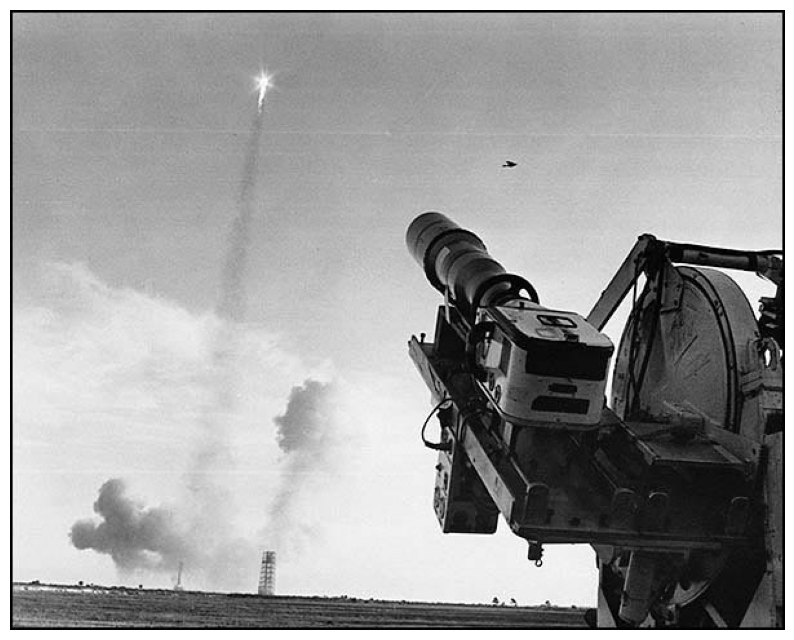

In [16]:
frame_src = cv2.imread("data/images/Apollo-8-Launch.png")
plt.figure(figsize = [10,10])
plt.axis("off")
plt.imshow(cv2.cvtColor(frame_src, cv2.COLOR_BGR2RGB))

# Get the image corners of the source image.
pts_src = [[0,0], [frame_src.shape[1], 0], [frame_src.shape[1], frame_src.shape[0]], [0, frame_src.shape[0]]]

pts_src_m = np.asarray(pts_src)
pts_dst_m = np.asarray(pts_dst)

(np.float64(-0.5), np.float64(1999.5), np.float64(1499.5), np.float64(-0.5))

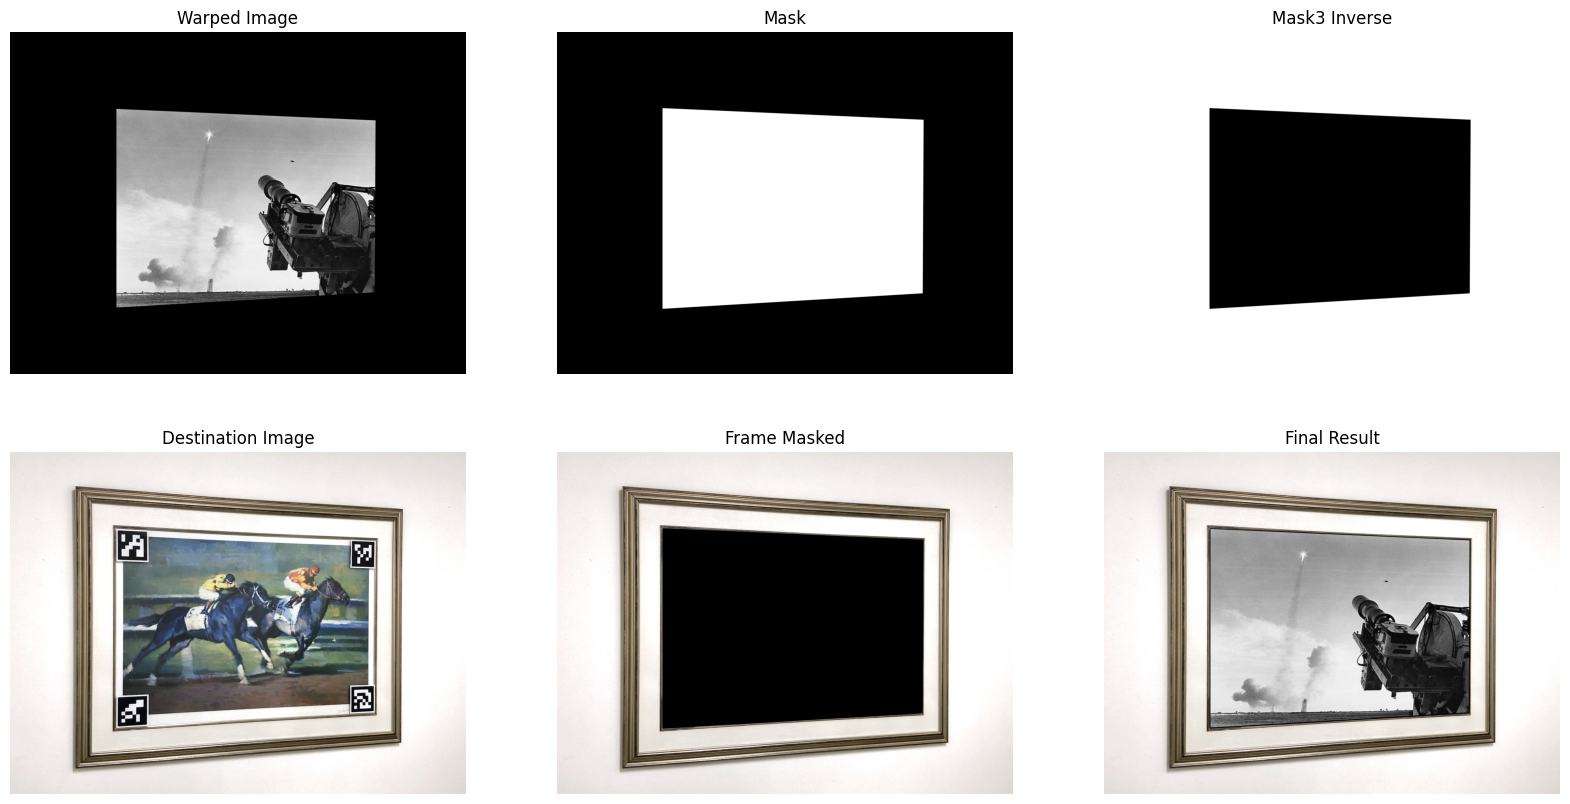

In [17]:
h, mask = cv2.findHomography(pts_src_m, pts_dst_m, cv2.RANSAC)

warped_image = cv2.warpPerspective(frame_src, h, (frame_dst.shape[1], frame_dst.shape[0]))

warped_image_copy = warped_image.copy()

mask = np.zeros([frame_dst.shape[0], frame_dst.shape[1]], dtype=np.uint8)

cv2.fillConvexPoly(mask, np.int32([pts_dst_m]), (255, 255, 255), cv2.LINE_AA)

warped_image = warped_image.astype(float)
mask3 = np.zeros_like(warped_image)

for i in range(0, 3):
    mask3[:, :, i] = mask / 255

mask3_inv = 1 - mask3

frame_masked = cv2.multiply(frame_dst.astype(float), mask3_inv)

frame_out = cv2.add(warped_image, frame_masked)

frame_masked = np.uint8(frame_masked)
frame_out = frame_out.astype(np.uint8)

plt.figure(figsize = [20,10])
plt.subplot(2,3,1); plt.imshow(warped_image_copy);        plt.title('Warped Image');      plt.axis('off')
plt.subplot(2,3,2); plt.imshow(mask);                     plt.title('Mask');              plt.axis('off')
plt.subplot(2,3,3); plt.imshow(mask3_inv);                plt.title('Mask3 Inverse');     plt.axis('off')
plt.subplot(2,3,4); plt.imshow(frame_dst[:, :, ::-1]);    plt.title('Destination Image'); plt.axis('off')
plt.subplot(2,3,5); plt.imshow(frame_masked[:, :, ::-1]); plt.title('Frame Masked');      plt.axis('off')
plt.subplot(2,3,6); plt.imshow(frame_out[:, :, ::-1]);    plt.title('Final Result');      plt.axis('off')


#### Application: Augmented Reality using ArUco Markers

In [19]:
!pip install mime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for mime: filename=mime-0.1.0-py3-none-any.whl size=39126 sha256=7927c8f600ab16aeed0d479feb9a8bd1ac94f2c3f6105143655070dc4370fc57
  Stored in directory: c:\users\ajay kumar br\appdata\local\pip\cache\wheels\75\77\69\2236ceb484e88cca43cc5871a766d1d57c19838708d280820e
Successfully built mime

   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   -----------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mime
import mimetypes

%matplotlib inline

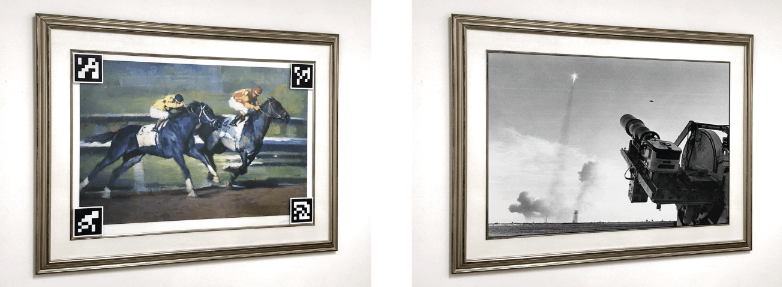

In [21]:
from IPython.display import Image

Image('data/images/AR_image_in_image_Apollo-8-launch.jpg')

In [26]:
!pip install imageio imageio-ffmpeg


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from IPython.display import Video

Video("data/videos/AR_image_in_video_New_Zealand_Cove.mp4", width=1000)

In [30]:
mimetypes.init()

case1_img_in_img = ['Apollo-8-launch.png',  'office_markers.jpg']
case2_img_in_vid = ['New_Zealand_Cove.jpg', 'office_markers.mp4']
case3_vid_in_img = ['boys_playing.mp4',     'office_markers.jpg']
case4_vid_in_vid = ['horse_race.mp4',       'office_markers.mp4']

case = case4_vid_in_vid

marker_ids = [23, 25, 30, 33]

# Scale factors used to increase size of source media to cover ArUco Marker borders.
scaling_fac_x = .008 
scaling_fac_y = .012

# Specify the prefix for the output file. The output file media type
# will depend on the source and destination media type.
prefix = 'AR_'

class MediaSpec:
    def __init__(self, src, dst):
        self.src = src
        self.dst = dst
        
media_spec = MediaSpec(case[0], case[1])

# The source may be either an image or video.
src_input = media_spec.src

# The destination may be either an image or video.
dst_input = media_spec.dst

# Determine the media types for source and destination.
mime_dst = mimetypes.guess_type(dst_input)[0]
if mime_dst != None:
    mime_dst = mime_dst.split('/')[0]
mime_src = mimetypes.guess_type(src_input)[0]
if mime_src != None:
     mime_src = mime_src.split('/')[0]

In [31]:
if mime_dst == 'image':
    # Read the image.
    frame_dst = cv2.imread(dst_input)
elif mime_dst == 'video':
    # Create a video capture object.
    cap_dst = cv2.VideoCapture(dst_input)
    fps = cap_dst.get(cv2.CAP_PROP_FPS)

In [32]:
if mime_src == 'image':
    # Read the image.
    frame_src = cv2.imread(src_input)
elif mime_src == 'video':
    # Create a video capture object.
    cap_src = cv2.VideoCapture(src_input)
    fps = cap_src.get(cv2.CAP_PROP_FPS)

In [33]:
if (mime_dst == 'video' or mime_src == 'video'):
    
    output_file = prefix + str(mime_src) + '_in_' + str(mime_dst) + '_'  + str(src_input[:-4]) + '.mp4'
    
    if mime_dst == 'video':
        # Determine the output video size based on the destination video frame size.
        width = round(2 * cap_dst.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = round(cap_dst.get(cv2.CAP_PROP_FRAME_HEIGHT))
    else:
        # Determine the output video size based on the destination image frame size.
        width = round(2 * frame_dst.shape[1])
        height = round(frame_dst.shape[0])
        
    # Create the video writer object.
    video_writer = cv2.VideoWriter(output_file, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
else:
    output_file = prefix + 'image_in_image_' + str(src_input[:-4]) + '.jpg'

In [34]:
def extract_pts(marker_ids, ids, corners):

    # Upper left corner of ROI.
    index = np.squeeze(np.where(ids == marker_ids[0]))
    ref_pt1 = np.squeeze(corners[index[0]])[0]

    # Upper right corner of ROI.
    index = np.squeeze(np.where(ids == marker_ids[1]))
    ref_pt2 = np.squeeze(corners[index[0]])[1]

    # Lower right corner of ROI.
    index = np.squeeze(np.where(ids == marker_ids[2]))
    ref_pt3 = np.squeeze(corners[index[0]])[2]

    # Lower left corner of ROI.
    index = np.squeeze(np.where(ids == marker_ids[3]));
    ref_pt4 = np.squeeze(corners[index[0]])[3]

    return ref_pt1, ref_pt2, ref_pt3, ref_pt4

In [35]:
def scale_dst_points(ref_pt1, ref_pt2, ref_pt3, ref_pt4, scaling_fac_x = 0.01, scaling_fac_y = 0.01):

    # Compute horizontal and vertical distance between markers.
    x_distance = np.linalg.norm(ref_pt1 - ref_pt2) # distance between upper left and upper right markers.
    y_distance = np.linalg.norm(ref_pt1 - ref_pt4) # distance between upper left and lower left markers.

    delta_x = round(scaling_fac_x * x_distance)
    delta_y = round(scaling_fac_y * y_distance)

    # Apply the scaling factors to the ArUco Marker reference points to make
    # the final adjustment for the destination points.
    pts_dst = [[ref_pt1[0] - delta_x, ref_pt1[1] - delta_y]]
    pts_dst = pts_dst + [[ref_pt2[0] + delta_x, ref_pt2[1] - delta_y]]
    pts_dst = pts_dst + [[ref_pt3[0] + delta_x, ref_pt3[1] + delta_y]]
    pts_dst = pts_dst + [[ref_pt4[0] - delta_x, ref_pt4[1] + delta_y]]

    return pts_dst

In [36]:
src_has_frame = True
dst_has_frame = True
frame_count = 0
max_frames = 100
color = (255,255,255)

# Load the dictionary that was used to generate the markers.
dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)

# Initialize the detector parameters using default values.
#parameters = cv2.aruco.DetectorParameters_create()

In [37]:
print('Processing frames ...')
while src_has_frame & dst_has_frame:

    if mime_dst == 'video':
        # Get frame from the destination video.
        dst_has_frame, frame_dst = cap_dst.read()
        if not dst_has_frame:
            break

    if mime_src == 'video':
        # The source is a video, so retrieve the source frame.
        src_has_frame, frame_src = cap_src.read()
        if not src_has_frame:
            break

    # Detect the markers in the image.
    corners, ids, rejected = cv2.aruco.detectMarkers(frame_dst, dictionary)

    # Extract reference point coordinates from marker corners.
    ref_pt1, ref_pt2, ref_pt3, ref_pt4 = extract_pts(marker_ids, ids, corners)

    # Scale destination points.
    pts_dst = scale_dst_points(ref_pt1, ref_pt2, ref_pt3, ref_pt4, 
                                   scaling_fac_x = scaling_fac_x, 
                                   scaling_fac_y = scaling_fac_y)

    # The source points are the four corners of the image source frame.
    pts_src = [[0,0], [frame_src.shape[1], 0], [frame_src.shape[1], frame_src.shape[0]], [0, frame_src.shape[0]]]

    # Convert list of points to arrays.
    pts_src_m = np.asarray(pts_src)
    pts_dst_m = np.asarray(pts_dst)

    # Calculate the hmography.
    h, mask = cv2.findHomography(pts_src_m, pts_dst_m, cv2.RANSAC)

    # Warp source image onto the destination image.
    warped_image = cv2.warpPerspective(frame_src, h, (frame_dst.shape[1], frame_dst.shape[0]))

    # Prepare a mask representing the region to copy from the warped image into the destination frame.
    mask = np.zeros([frame_dst.shape[0], frame_dst.shape[1]], dtype=np.uint8);
     
    # Fill ROI in destination frame with white to create mask.
    cv2.fillConvexPoly(mask, np.int32([pts_dst_m]), (255, 255, 255), cv2.LINE_AA);

    # Copy the mask into 3 channels.
    warped_image = warped_image.astype(float)
    mask3 = np.zeros_like(warped_image)
    for i in range(0, 3):
        mask3[:, :, i] = mask / 255
    
    # Create black region in destination frame ROI.
    frame_masked = cv2.multiply(frame_dst.astype(float), 1 - mask3)
    
    # Create final result by adding warped image with the masked destination frame.
    frame_out = cv2.add(warped_image, frame_masked)

    # Showing the original frame and the new output frame side by side.
    concatenated_output = cv2.hconcat([frame_dst.astype(float), frame_out])

    # Draw a white vertical line that divides the two image frames.
    frame_w = concatenated_output.shape[1]
    frame_h = concatenated_output.shape[0]
    concatenated_output = cv2.line(concatenated_output, 
                                   (int(frame_w / 2), 0), 
                                   (int(frame_w / 2), frame_h), 
                                   color, thickness = 8)

    # Create output file.
    if (mime_dst == 'image' and mime_src == 'image'):
        # Create output image.
        cv2.imwrite(output_file, concatenated_output.astype(np.uint8))
        break
    else:
        # Create output video.
        video_writer.write(concatenated_output.astype(np.uint8))
        
cv2.destroyAllWindows()
if 'video_writer' in locals():
    video_writer.release()
    print('Processing complete, video writer released ...')

Processing frames ...
Processing complete, video writer released ...
